In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt 

In [2]:
oil_sp_ticker = ["CVX", "SHEL", "XOM", "^GSPC"]

my_portfolio = yf.download(oil_sp_ticker, start="2010-01-01", end="2026-01-01")["Close"]

[*********************100%***********************]  4 of 4 completed


In [3]:
my_portfolio.head()

Ticker,CVX,SHEL,XOM,^GSPC
Date,,,,
2010-01-04,41.265465,27.279518,37.630978,1132.989990
2010-01-05,41.557735,27.310148,37.777908,1136.520020
2010-01-06,41.562962,27.087009,38.104431,1137.140015
2010-01-07,41.406376,26.955753,37.984707,1141.689941
2010-01-08,41.479443,26.916367,37.832336,1144.979980


In [4]:
my_portfolio.tail()

Ticker,CVX,SHEL,XOM,^GSPC
Date,,,,
2025-12-24,149.042023,72.165787,118.430618,6932.049805
2025-12-26,148.566666,72.136070,118.321342,6929.939941
2025-12-29,149.527267,72.443207,119.731941,6905.740234
2025-12-30,150.834473,73.146629,120.188896,6896.240234
2025-12-31,150.933517,72.799873,119.543198,6845.500000


In [5]:
my_portfolio.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CVX     4024 non-null   float64
 1   SHEL    4024 non-null   float64
 2   XOM     4024 non-null   float64
 3   ^GSPC   4024 non-null   float64
dtypes: float64(4)
memory usage: 157.2 KB


In [6]:
normalization = (my_portfolio / my_portfolio.iloc[0]) * 100
print(normalization.head())

Ticker             CVX        SHEL         XOM       ^GSPC
Date                                                      
2010-01-04  100.000000  100.000000  100.000000  100.000000
2010-01-05  100.708269  100.112282  100.390451  100.311568
2010-01-06  100.720934   99.294310  101.258148  100.366290
2010-01-07  100.341475   98.813158  100.939995  100.767875
2010-01-08  100.518540   98.668776  100.535088  101.058261


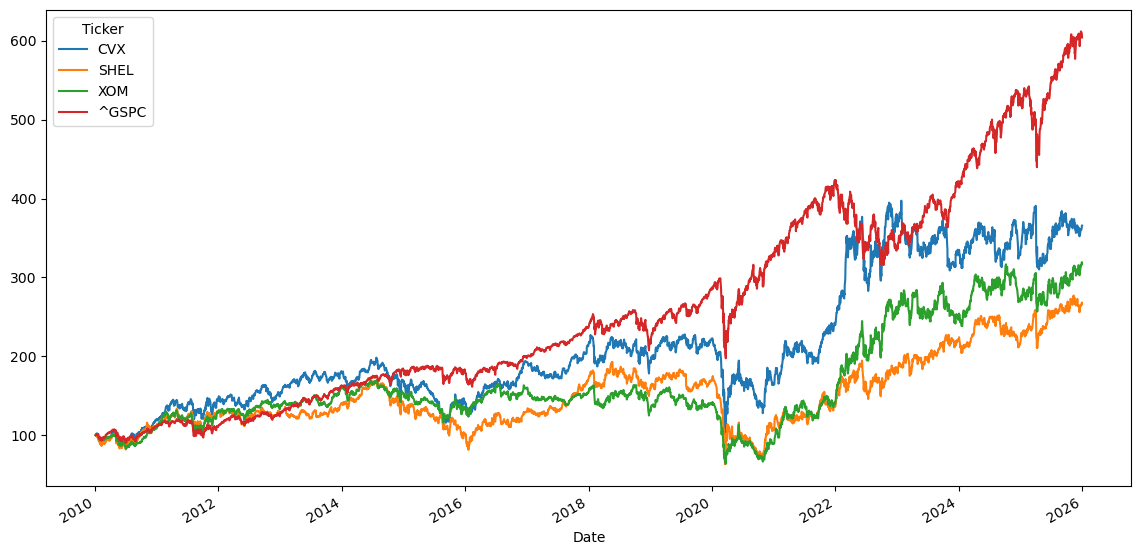

CVX demonstrated the highest resilience during market downturns. Over the decade, the index yielded the highest cumulative return, followed by SHEL.


In [27]:
normalization.plot(figsize=(14,7))
plt.show()
print("CVX demonstrated the highest resilience during market downturns. Over the decade, the index yielded the highest cumulative return, followed by SHEL.")

In [8]:
simple_daily_return = normalization.pct_change()
print(simple_daily_return.head())

Ticker           CVX      SHEL       XOM     ^GSPC
Date                                              
2010-01-04       NaN       NaN       NaN       NaN
2010-01-05  0.007083  0.001123  0.003905  0.003116
2010-01-06  0.000126 -0.008171  0.008643  0.000546
2010-01-07 -0.003767 -0.004846 -0.003142  0.004001
2010-01-08  0.001765 -0.001461 -0.004011  0.002882


In [9]:
average_annual_return = simple_daily_return.mean() * 250
print(average_annual_return)

Ticker
CVX      0.115976
SHEL     0.099268
XOM      0.102514
^GSPC    0.126742
dtype: float64


In [10]:
weight = np.array([0.30, 0.30, 0.40])
print(weight)

[0.3 0.3 0.4]


In [23]:
annual_return = average_annual_return[["CVX", "SHEL", "XOM"]]
print(annual_return)

Ticker
CVX     0.115976
SHEL    0.099268
XOM     0.102514
dtype: float64


In [24]:
final_expected_annual_return = np.dot(weight, annual_return)
print(final_expected_annual_return)

0.10557882375698377


In [28]:
print(f'The expected annual return of the Oil & Gas portfolio is {round(final_expected_annual_return * 100,2)}%')

The expected annual return of the Oil & Gas portfolio is 10.56%


In [29]:
print(f'The expected annual return of the S&P 500 benchmark is: 12.67%')

The expected annual return of the S&P 500 benchmark is: 12.67%


# Based on these figures, while the S&P 500 outperformed the three-stock portfolio, 
# an equity-focused strategy within this sector would prioritize CVX, followed by XOM. 
# Therefore, heavier portfolio weighting will be allocated to these specific assets.